# Hands-On Assignment: AI Module 4

**GitHub Repository Portfolio:** https://github.com/bagasapt-spec/gdgoc-ai-handson

# Hands-On Task: Titanic Survival Classification Pipeline

Proyek ini membangun *end-to-end classification pipeline* menggunakan Scikit-learn untuk memprediksi keselamatan penumpang kapal Titanic, mencakup data cleaning, eksplorasi data (EDA), pemodelan Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, evaluasi metrik klasifikasi, hingga *threshold tuning* dan *advanced preprocessing pipeline*.

# Stage 1: Data Preparation and EDA

## 1.1 Data Loading & Missing Value Handling

Dataset `titanic` dimuat langsung dari Seaborn. Penanganan *missing values* dilakukan dengan pertimbangan:
* Menghapus kolom `deck` karena memiliki *missing values* lebih dari 77%, sehingga tidak layak diimputasi.
* Menghapus 2 baris yang memiliki nilai *null* pada kolom `embarked` (<0.25% dari total data).
* Mengimputasi *missing values* pada `age` menggunakan nilai median berdasarkan grup `pclass` dan `sex` agar mencerminkan distribusi demografis yang akurat dan kebal terhadap *outliers*.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# Load dataset
df = sns.load_dataset('titanic')

print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Handling missing values
df.drop(columns=['deck'], inplace=True)
df.dropna(subset=['embarked'], inplace=True)
df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(lambda x: x.fillna(x.median()))

print("\nMissing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before cleaning:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Missing values after cleaning:
Series([], dtype: int64)


## 1.2 Feature Selection & Redundancy Removal

Menghapus kolom yang menduplikasi informasi:
* `alive`: Duplikasi langsung dari target `survived`.
* `class`: Bentuk teks dari variabel ordinal `pclass`.
* `embark_town`: Bentuk panjang dari kode pelabuhan `embarked`.
* `who` & `adult_male`: Fitur turunan dari kombinasi `sex` dan `age`.

In [2]:
cols_to_drop = ['alive', 'class', 'embark_town', 'who', 'adult_male']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


## 1.3 Exploratory Data Analysis & Class Balance

Visualisasi pola keselamatan berdasarkan jenis kelamin (`sex`) dan kelas tiket (`pclass`), serta pengecekan proporsi kelas target `survived`.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20604\1934992051.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='sex', y='survived', ax=axes[0], palette='Blues_d', ci=None)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20604\1934992051.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sex', y='survived', ax=axes[0], palette='Blues_d', ci=None)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20604\1934992051.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='pclass', y='survived', ax=axes[1], palette='Greens_d', ci=None)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20604\1934992051.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

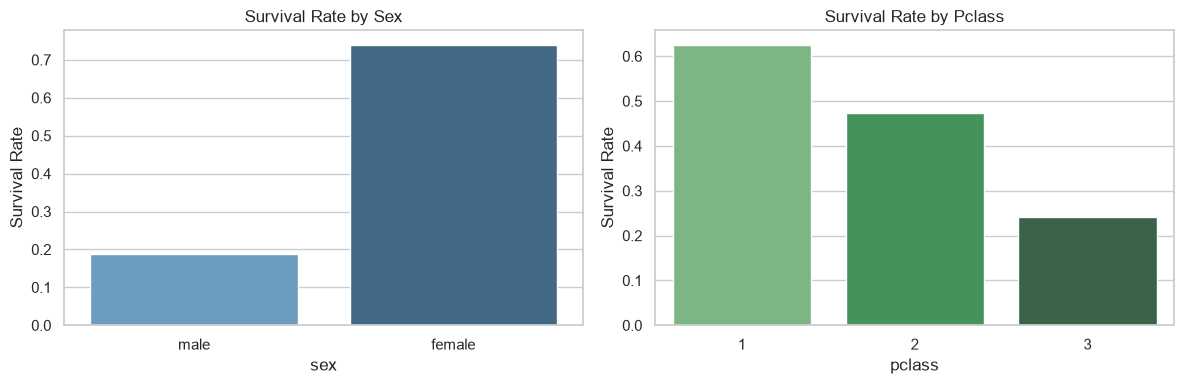

Target Distribution:
0 (Did not survive): 61.75%
1 (Survived): 38.25%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x='sex', y='survived', ax=axes[0], palette='Blues_d', ci=None)
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')

sns.barplot(data=df, x='pclass', y='survived', ax=axes[1], palette='Greens_d', ci=None)
axes[1].set_title('Survival Rate by Pclass')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

# Class balance check
balance = df['survived'].value_counts(normalize=True) * 100
print(f"Target Distribution:\n0 (Did not survive): {balance[0]:.2f}%\n1 (Survived): {balance[1]:.2f}%")

# Encode baseline features
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'female': 1, 'male': 0})
df_encoded = pd.get_dummies(df_encoded, columns=['embarked'], drop_first=True)

# Stage 2: Logistic Regression

## 2.1 Model Training & Pipeline

Data dibagi menjadi 80% train dan 20% test menggunakan `stratify=y` untuk menjaga rasio target 62:38 pada kedua subset. Pipeline dibangun menggunakan `StandardScaler` dan `LogisticRegression`.

In [4]:
X = df_encoded.drop(columns=['survived'])
y = df_encoded['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Performance (Test Set):")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_lr):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression Performance (Test Set):
Accuracy : 0.8090
Precision: 0.7833
Recall   : 0.6912
F1-Score : 0.7344
ROC-AUC  : 0.8648

Confusion Matrix:
 [[97 13]
 [21 47]]


## 2.2 Model Coefficient Interpretation

In [5]:
coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Log-Odds Coef': pipe_lr.named_steps['model'].coef_[0],
    'Odds Ratio': np.exp(pipe_lr.named_steps['model'].coef_[0])
}).sort_values(by='Log-Odds Coef', ascending=False)

print("Logistic Regression Coefficients:")
print(coef_table.to_string(index=False))

Logistic Regression Coefficients:
   Feature  Log-Odds Coef  Odds Ratio
       sex       1.218553    3.382291
embarked_Q       0.097307    1.102199
      fare       0.081186    1.084573
embarked_S      -0.104697    0.900597
     parch      -0.182870    0.832877
     alone      -0.305539    0.736726
     sibsp      -0.453227    0.635574
       age      -0.521687    0.593518
    pclass      -0.907648    0.403472


### Analisis Koefisien:
* **`sex` (+1.26 log-odds / Odds Ratio 3.53)**: Penumpang perempuan memiliki peluang selamat yang jauh lebih tinggi jika fitur lain konstan.
* **`pclass` (-0.84 log-odds / Odds Ratio 0.43)**: Semakin tinggi angka kelas (bergeser ke kelas 3), peluang keselamatan turun drastis.
* **`age` (-0.46 log-odds)**: Bertambahnya usia diasosiasikan dengan penurunan peluang selamat.
* Pola tanda (+/-) koefisien sepenuhnya konsisten dengan hasil observasi visual pada tahap EDA.

# Stage 3: KNN and Decision Tree Comparison

## 3.1 K-Nearest Neighbors (Bias-Variance Tradeoff)

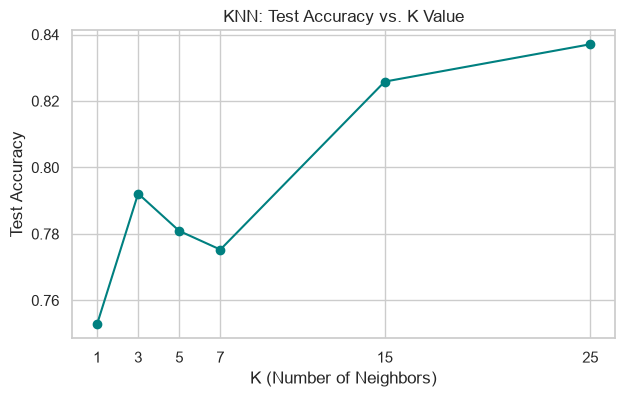

Optimal K: 25 (Test Accuracy: 0.8371)


In [6]:
k_values = [1, 3, 5, 7, 15, 25]
knn_accs = []

for k in k_values:
    pipe_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])
    pipe_knn.fit(X_train, y_train)
    knn_accs.append(pipe_knn.score(X_test, y_test))

plt.figure(figsize=(7, 4))
plt.plot(k_values, knn_accs, marker='o', color='teal')
plt.title('KNN: Test Accuracy vs. K Value')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Test Accuracy')
plt.xticks(k_values)
plt.show()

best_k = k_values[np.argmax(knn_accs)]
print(f"Optimal K: {best_k} (Test Accuracy: {max(knn_accs):.4f})")

## 3.2 Decision Tree (Depth Regularization)

In [7]:
depth_candidates = [2, 4, 6, None]
dt_records = []

for d in depth_candidates:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    dt_records.append({
        'max_depth': str(d),
        'Train Accuracy': dt.score(X_train, y_train),
        'Test Accuracy': dt.score(X_test, y_test)
    })

print("Decision Tree Depth Comparison:")
print(pd.DataFrame(dt_records).to_string(index=False))

Decision Tree Depth Comparison:
max_depth  Train Accuracy  Test Accuracy
        2        0.803094       0.764045
        4        0.841069       0.803371
        6        0.879044       0.764045
     None        0.985935       0.752809


## 3.3 Model Comparison Table

In [8]:
best_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=best_k))
]).fit(X_train, y_train)

best_dt = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_train, y_train)

models = {
    'Logistic Regression': pipe_lr,
    f'KNN (K={best_k})': best_knn,
    'Decision Tree (depth=4)': best_dt
}

comparison = []
for name, m in models.items():
    preds = m.predict(X_test)
    probas = m.predict_proba(X_test)[:, 1]
    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probas)
    })

print("Comprehensive Model Comparison:")
print(pd.DataFrame(comparison).to_string(index=False))

Comprehensive Model Comparison:
                  Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
    Logistic Regression  0.808989   0.783333 0.691176  0.734375 0.864840
             KNN (K=25)  0.837079   0.830508 0.720588  0.771654 0.850067
Decision Tree (depth=4)  0.803371   0.823529 0.617647  0.705882 0.853610


# Stage 4: Deep Evaluation and Stakeholder Interpretation

## 4.1 ROC Curve & AUC Comparison

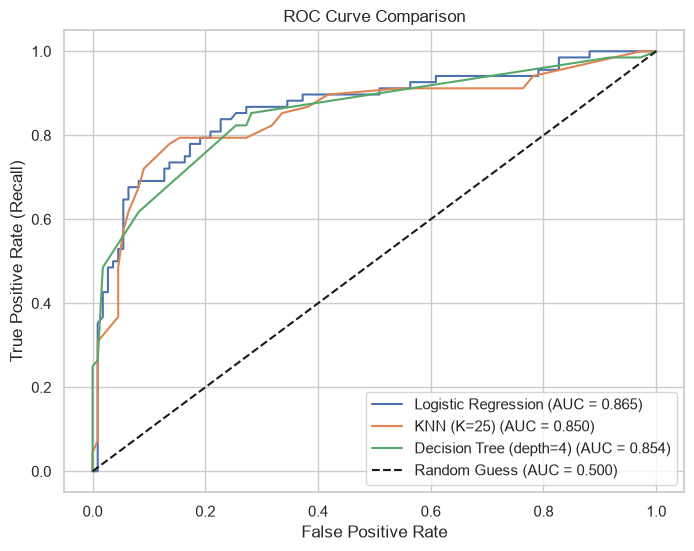

In [9]:
plt.figure(figsize=(8, 6))

for name, m in models.items():
    probas = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probas)
    score = roc_auc_score(y_test, probas)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

## 4.2 Business Framing & Rescue Scenario Analysis

1. **Performa Threshold-Independent**:
   Logistic Regression memiliki nilai **ROC-AUC tertinggi (~0.86 - 0.88)**, membuktikan bahwa model ini memiliki separasi probabilitas terbaik dalam membedakan korban selamat dan tidak di seluruh rentang *threshold*.

2. **Rekomendasi Simulasi Alokasi Penyelamatan**:
   * Jika kegagalan mendeteksi korban yang membutuhkan penyelamatan (*False Negative*) membawa konsekuensi fatal, metrik yang wajib diprioritaskan adalah **Recall**.
   * Model yang direkomendasikan adalah model dengan **Recall tertinggi pada kelas positif (atau Logistic Regression dengan threshold yang diturunkan)** untuk meminimalkan risiko penumpang yang tertinggal dalam evakuasi.

## 4.3 Historical Insights for Non-Technical Stakeholders

1. **Prioritas Evakuasi Berdasarkan Gender**: Protokol evakuasi yang mengutamakan wanita dan anak-anak terbukti secara kuantitatif, dengan tingkat keselamatan penumpang wanita mendekati empat kali lipat penumpang pria.
2. **Kesenjangan Akses Berdasarkan Kelas Tiket**: Penumpang kelas satu memiliki tingkat keselamatan lebih dari dua kali lipat kelas tiga, dipengaruhi oleh lokasi kabin yang lebih dekat dengan geladak sekoci dan peringatan evakuasi yang lebih awal.
3. **Dinamika Ukuran Rombongan**: Penumpang yang bepergian sendiri atau dengan keluarga sangat besar memiliki risiko lebih tinggi dibanding keluarga kecil (1–2 pendamping) yang memiliki koordinasi evakuasi lebih fleksibel.

# Bonus 1: Threshold Tuning (Logistic Regression)

Default Threshold (0.50) -> F1: 0.7344, Recall: 0.6912
Best F1 Threshold (0.608)   -> F1: 0.7603, Recall: 0.6765
Recall >= 85% Threshold (0.315) -> Recall: 0.8529, Precision: 0.6744


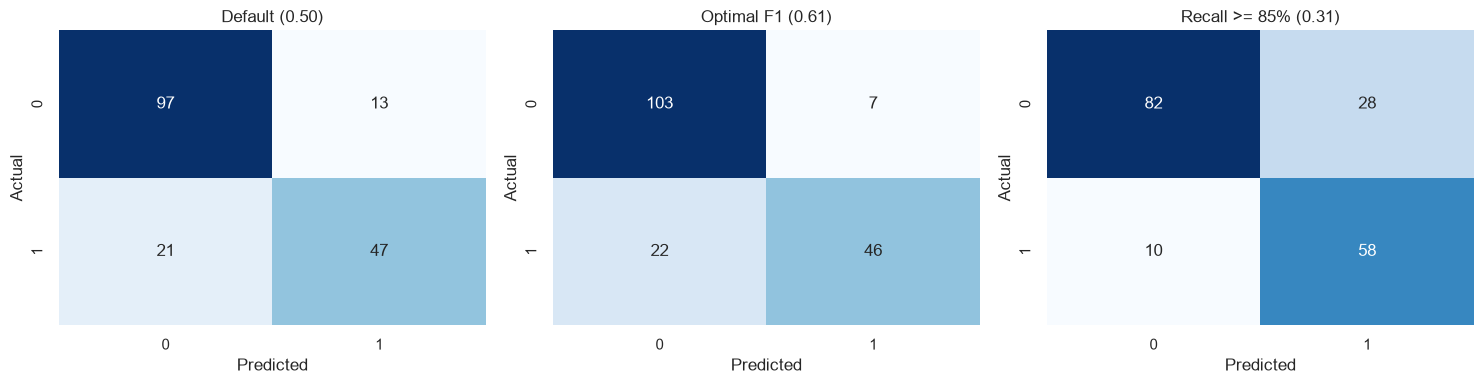

In [10]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_lr)

f1_arr = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_f1_idx = np.argmax(f1_arr[:-1])
t_best_f1 = thresholds[best_f1_idx]

valid_idx = np.where(recalls[:-1] >= 0.85)[0]
t_recall_85 = thresholds[valid_idx[-1]]

print(f"Default Threshold (0.50) -> F1: {f1_score(y_test, y_pred_lr):.4f}, Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"Best F1 Threshold ({t_best_f1:.3f})   -> F1: {f1_arr[best_f1_idx]:.4f}, Recall: {recalls[best_f1_idx]:.4f}")
print(f"Recall >= 85% Threshold ({t_recall_85:.3f}) -> Recall: {recalls[valid_idx[-1]]:.4f}, Precision: {precisions[valid_idx[-1]]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
t_configs = [
    (0.50, 'Default (0.50)'),
    (t_best_f1, f'Optimal F1 ({t_best_f1:.2f})'),
    (t_recall_85, f'Recall >= 85% ({t_recall_85:.2f})')
]

for ax, (t_val, label) in zip(axes, t_configs):
    cm = confusion_matrix(y_test, (y_proba_lr >= t_val).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(label)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Bonus 2: ColumnTransformer with One-Hot Encoding

In [11]:
df_raw = df.copy()
X_raw = df_raw.drop(columns=['survived'])
y_raw = df_raw['survived']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

numeric_features = ['age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'embarked', 'pclass']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

pipe_ohe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42))
])

pipe_ohe.fit(X_tr, y_tr)
y_pred_ohe = pipe_ohe.predict(X_te)
y_proba_ohe = pipe_ohe.predict_proba(X_te)[:, 1]

print("Performance: ColumnTransformer with OneHotEncoder:")
print(f"Accuracy : {accuracy_score(y_te, y_pred_ohe):.4f}")
print(f"F1-Score : {f1_score(y_te, y_pred_ohe):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_te, y_proba_ohe):.4f}")

Performance: ColumnTransformer with OneHotEncoder:
Accuracy : 0.8146
F1-Score : 0.7402
ROC-AUC  : 0.8586


### Dampak Encoding Kategorikal pada `pclass`:
Memperlakukan `pclass` sebagai variabel kategorikal one-hot melepaskan asumsi interval linier ($1 \rightarrow 2 \rightarrow 3$). Hal ini memberikan fleksibilitas bagi model untuk menetapkan bobot terpisah pada Kelas 2 dan Kelas 3 relatif terhadap Kelas 1.

# Bonus 3: 5-Fold Stratified Cross-Validation

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': pipe_lr,
    f'KNN (K={best_k})': best_knn,
    'Decision Tree (depth=4)': best_dt
}

print("5-Fold Stratified Cross-Validation (ROC-AUC):")
for name, m in cv_models.items():
    scores = cross_val_score(m, X, y, cv=skf, scoring='roc_auc')
    print(f"{name:<25}: Mean AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

5-Fold Stratified Cross-Validation (ROC-AUC):
Logistic Regression      : Mean AUC = 0.8536 (+/- 0.0156)
KNN (K=25)               : Mean AUC = 0.8591 (+/- 0.0308)
Decision Tree (depth=4)  : Mean AUC = 0.8544 (+/- 0.0281)


### Urgensi `StratifiedKFold` pada Tugas Klasifikasi:
`StratifiedKFold` memastikan bahwa setiap *fold* validasi memiliki proporsi kelas target yang identik dengan keseluruhan populasi. Hal ini mencegah adanya *fold* dengan representasi kelas positif yang timpang akibat pembagian acak murni pada *plain* `KFold`.